In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

#### Satélite

In [2]:
path = "Copernicus"
filename = "buoy_satellite_index0.csv"
df_index0 = pd.read_csv(os.path.join(path, filename))
df_index0['Date'] = pd.to_datetime(df_index0['Date'])

filename = "buoy_satellite_index1.csv"
df_index1 = pd.read_csv(os.path.join(path, filename))
df_index1['Date'] = pd.to_datetime(df_index1['Date'])

filename = "buoy_satellite_index8.csv"
df_index8 = pd.read_csv(os.path.join(path, filename))
df_index8['Date'] = pd.to_datetime(df_index8['Date'])

# Porque los datos de lasboyas vienen sin guion
df_index0['Buoy'] = df_index0['Buoy'].str.replace('CTD-', 'CTD', regex=False)
df_index1['Buoy'] = df_index1['Buoy'].str.replace('CTD-', 'CTD', regex=False)
df_index8['Buoy'] = df_index8['Buoy'].str.replace('CTD-', 'CTD', regex=False)

# 1 dataframe por boya
dataframes_buoys_index0 = {buoy: group.reset_index(drop=True) for buoy, group in df_index0.groupby('Buoy')}
dataframes_buoys_index1 = {buoy: group.reset_index(drop=True) for buoy, group in df_index1.groupby('Buoy')}
dataframes_buoys_index8 = {buoy: group.reset_index(drop=True) for buoy, group in df_index8.groupby('Buoy')}

#### Boyas

In [55]:
# Ruta a la carpeta que contiene todas las boyas
path = "boyaUPCT/extractedData/"
# Listamos los nombres de todas las boyas
buoy_ids = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
# Diccionario para guardar dataframes
dataframes_boyas = {}

# Para cada boya cargamos todos sus csvs y los guardamos con key f"{bouy_id}_{variable}"
for buoy_id in buoy_ids:
    archivos_csv = [f for f in os.listdir(path + buoy_id) if f.endswith('.csv')]

    for archivo in archivos_csv:
        
        nombre_variable = os.path.splitext(archivo)[0]
        ruta_completa = os.path.join(path, buoy_id, archivo)
        # CARGAMOS SOLO CLOROFILA
        if nombre_variable in ["Clorofila", "Transparency"]:
            dataframes_boyas[f"{buoy_id}_{nombre_variable}"] = pd.read_csv(ruta_completa)
        
for key, df in dataframes_boyas.items():
    df['Date'] = pd.to_datetime(df['Date'])

In [5]:
date_index = pd.date_range(start='2021-01-01', end='2024-07-30')
base_df = pd.DataFrame({'Date': date_index})

In [22]:
merged_df = base_df.merge(dataframes_boyas["CTD7_Clorofila"][["Date", "4.0"]], on='Date', how='left').rename(columns={"0.5":"Clorofila_buoy"})
merged_df = merged_df.merge(dataframes_buoys_index0["CTD7"][["Date", "Pixel_Value"]], on='Date', how='left').rename(columns={"Pixel_Value":"Clorofila_index0"})
merged_df = merged_df.merge(dataframes_buoys_index1["CTD7"][["Date", "Pixel_Value"]], on='Date', how='left').rename(columns={"Pixel_Value":"Clorofila_index1"})
merged_df = merged_df.merge(dataframes_buoys_index8["CTD7"][["Date", "Pixel_Value"]], on='Date', how='left').rename(columns={"Pixel_Value":"Clorofila_index8"})

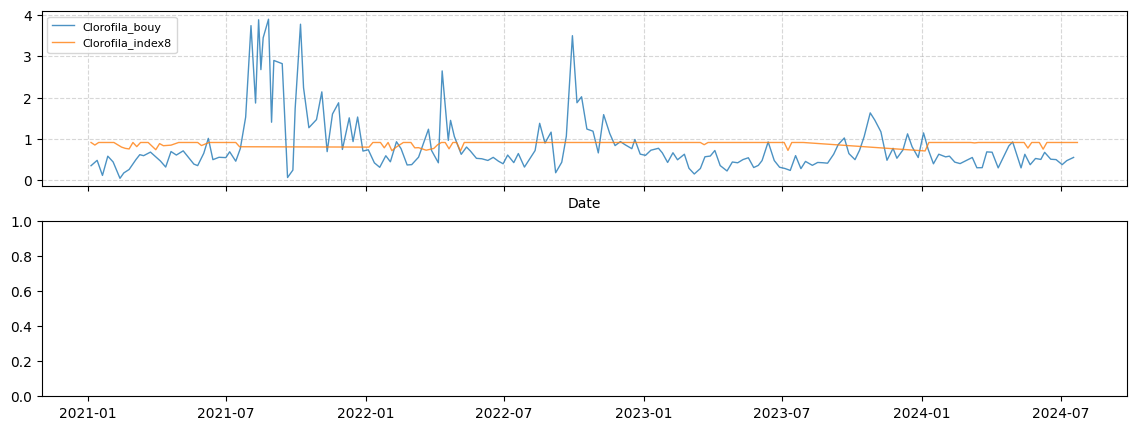

In [14]:
fig, ax = plt.subplots(figsize=(14, 5), nrows=2, ncols=1, sharex=True)

ax[0].plot(merged_df.dropna(subset=["Clorofila_buoy"])["Date"], merged_df.dropna(subset=["Clorofila_buoy"])["Clorofila_buoy"], linewidth=1, alpha = 0.8, label = "Clorofila_bouy")
# ax[0].plot(merged_df.dropna(subset=["Clorofila_index0"])["Date"], merged_df.dropna(subset=["Clorofila_index0"])["Clorofila_index0"], linewidth=1, alpha = 0.8, label = "Clorofila_index0")
# ax[0].plot(merged_df.dropna(subset=["Clorofila_index1"])["Date"], merged_df.dropna(subset=["Clorofila_index1"])["Clorofila_index1"], linewidth=1, alpha = 0.8, label = "Clorofila_index1")
ax[0].plot(merged_df.dropna(subset=["Clorofila_index8"])["Date"], merged_df.dropna(subset=["Clorofila_index8"])["Clorofila_index8"], linewidth=1, alpha = 0.8, label = "Clorofila_index8")
ax[0].set_title("")
ax[0].set_xlabel('Date')
ax[0].legend(loc='upper left', fontsize=8)
ax[0].grid(True, linestyle = '--', alpha = 0.5)


In [83]:
buoy

'CTD5'

In [82]:
dataframes_boyas["CTD1_Clorofila"][["Date", "0.5"]]

,Date,0.5
0,2017-05-19,0.107629
1,2017-05-24,0.227040
2,2017-06-02,0.126068
3,2017-06-06,0.107302
4,2017-06-13,0.115022
...,...,...
368,2024-06-18,0.239427
369,2024-06-25,0.196050
370,2024-07-03,0.229174
371,2024-07-09,0.312592


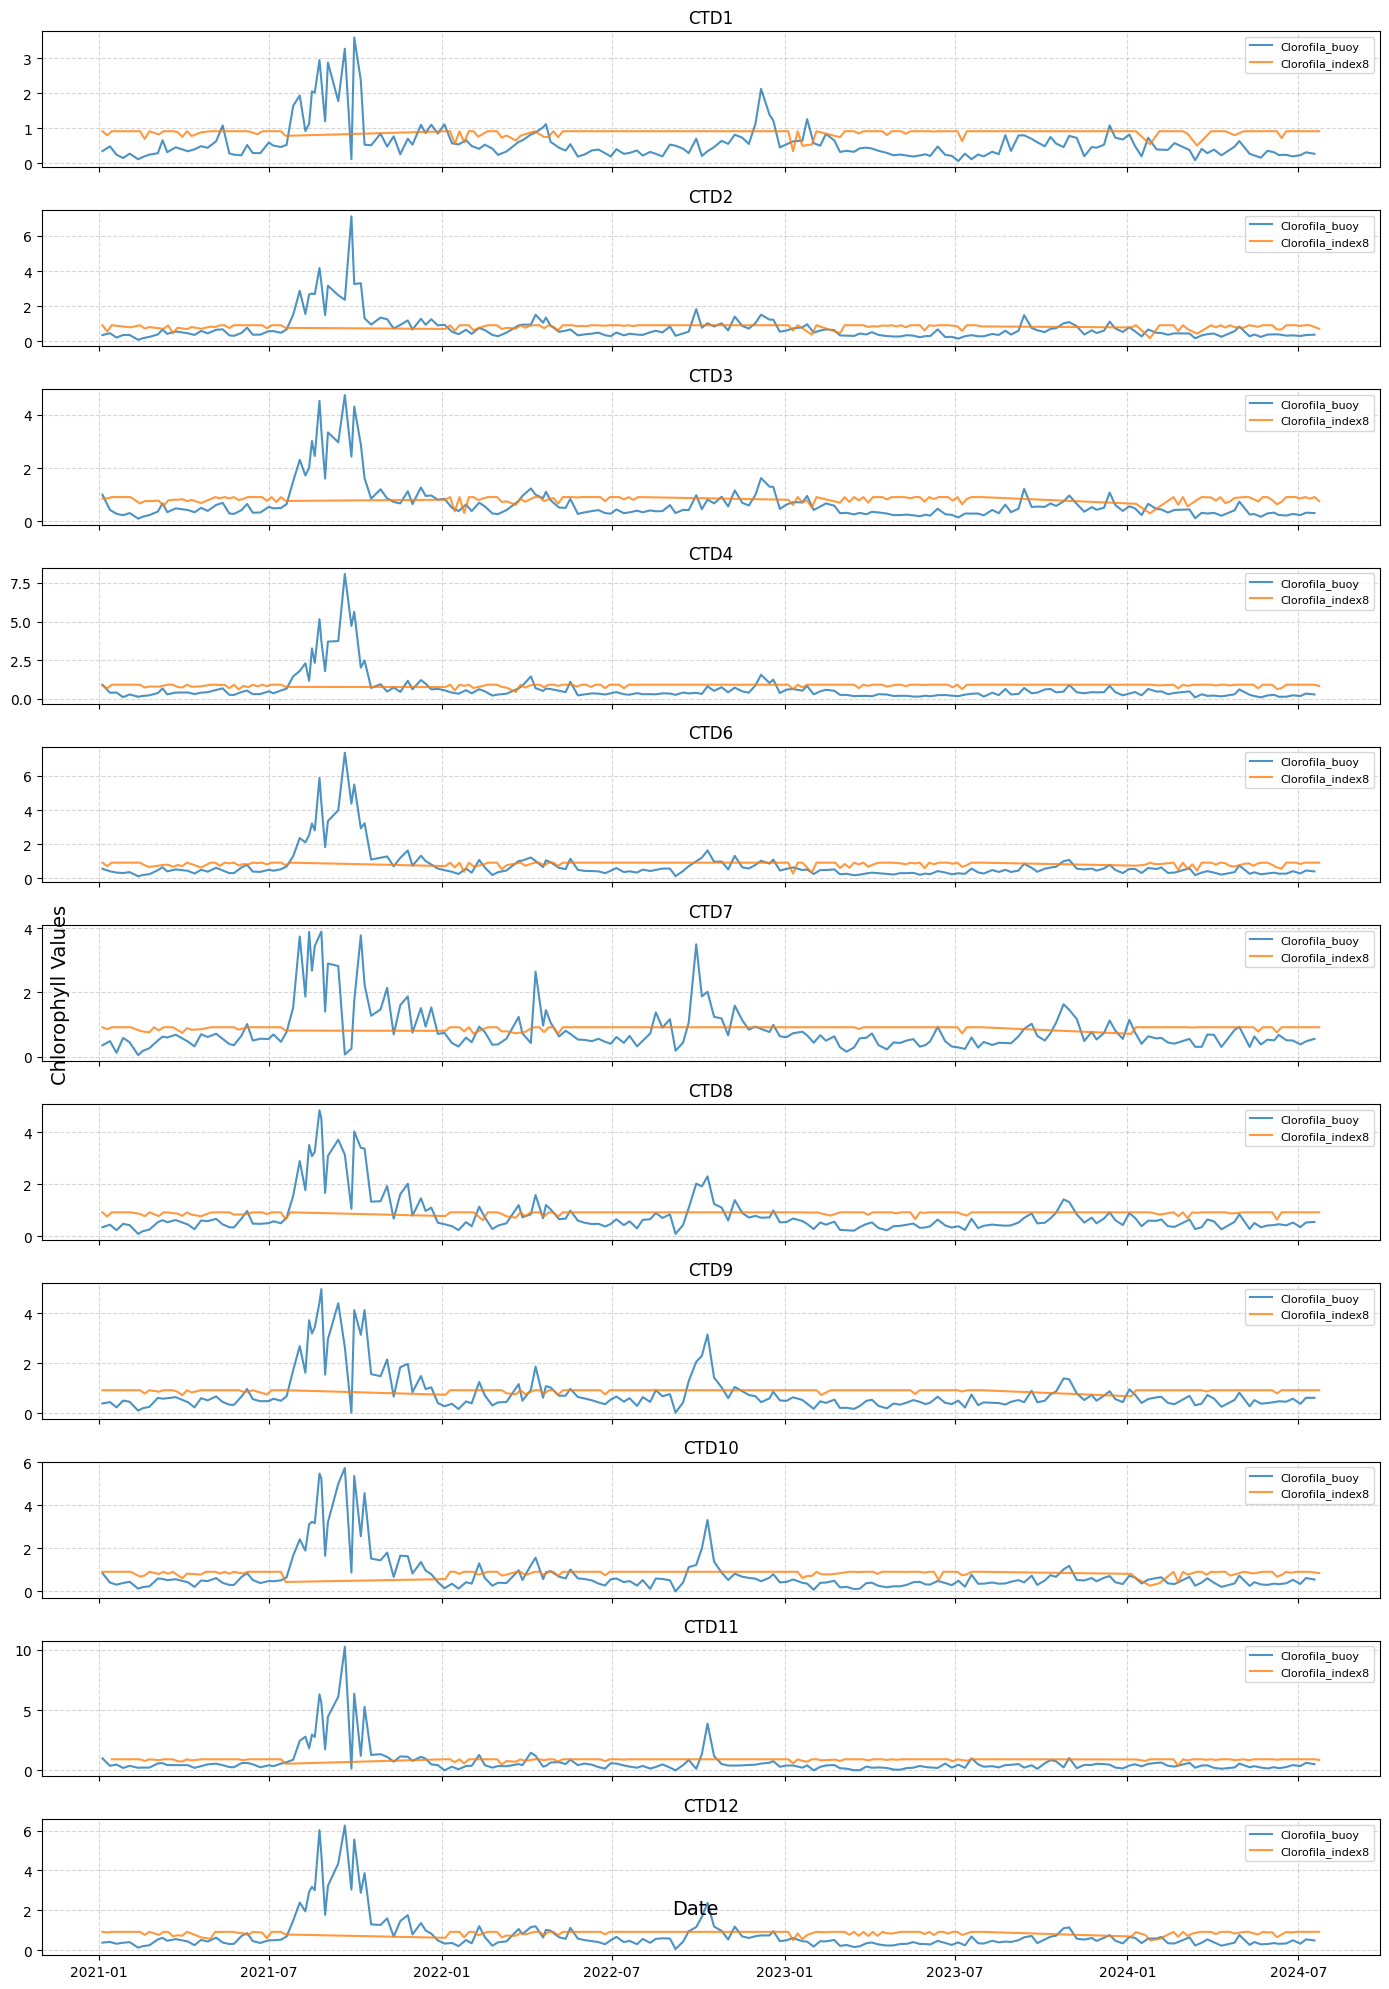

In [26]:
# Define the number of rows and columns for the subplots
nrows, ncols = 11, 1 
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 20), sharex=True, sharey=False)

# Flatten the axes array for easier indexing
axes = axes.flatten()

#merged_dfs = {}

# Loop through each buoy and its corresponding subplot
for i, buoy in enumerate([f"CTD{j}" for j in range(1, 13) if j != 5]):
    ax = axes[i]
    
    merged_df = base_df.merge(dataframes_boyas[f"{buoy}_Clorofila"][["Date", "0.5"]], on='Date', how='left').rename(columns={"0.5": f"Clorofila_buoy_{buoy}"})
    merged_df = merged_df.merge(dataframes_buoys_index0[buoy][["Date", "Pixel_Value"]], on='Date', how='left').rename(columns={"Pixel_Value": f"Clorofila_index0_{buoy}"})
    merged_df = merged_df.merge(dataframes_buoys_index1[buoy][["Date", "Pixel_Value"]], on='Date', how='left').rename(columns={"Pixel_Value": f"Clorofila_index1_{buoy}"})
    merged_df = merged_df.merge(dataframes_buoys_index8[buoy][["Date", "Pixel_Value"]], on='Date', how='left').rename(columns={"Pixel_Value": f"Clorofila_index8_{buoy}"})

    # Store the merged DataFrame
    #merged_dfs[buoy] = merged_df
    # Plot each Clorofila column if it has valid data
    if merged_df[f"Clorofila_buoy_{buoy}"].notna().any():
        ax.plot(merged_df.dropna(subset=[f"Clorofila_buoy_{buoy}"])["Date"],
                merged_df.dropna(subset=[f"Clorofila_buoy_{buoy}"])[f"Clorofila_buoy_{buoy}"], 
                label="Clorofila_buoy", alpha=0.8)
    # if merged_df[f"Clorofila_index0_{buoy}"].notna().any():
    #     ax.plot(merged_df.dropna(subset=[f"Clorofila_index0_{buoy}"])["Date"],
    #             merged_df.dropna(subset=[f"Clorofila_index0_{buoy}"])[f"Clorofila_index0_{buoy}"], 
    #             label="Clorofila_index0", alpha=0.8)
    # if merged_df[f"Clorofila_index1_{buoy}"].notna().any():
    #     ax.plot(merged_df.dropna(subset=[f"Clorofila_index1_{buoy}"])["Date"],
    #             merged_df.dropna(subset=[f"Clorofila_index1_{buoy}"])[f"Clorofila_index1_{buoy}"], 
    #         label="Clorofila_index1", alpha=0.8)
    if merged_df[f"Clorofila_index8_{buoy}"].notna().any():
        ax.plot(merged_df.dropna(subset=[f"Clorofila_index8_{buoy}"])["Date"],
                merged_df.dropna(subset=[f"Clorofila_index8_{buoy}"])[f"Clorofila_index8_{buoy}"], 
            label="Clorofila_index8", alpha=0.8)

    # Customize the subplot
    ax.set_title(f"{buoy}")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)

# Adjust layout and add shared labels
plt.tight_layout()
fig.text(0.5, 0.04, 'Date', ha='center', fontsize=14)
fig.text(0.04, 0.5, 'Chlorophyll Values', va='center', rotation='vertical', fontsize=14)

plt.show()


### Clorofila a más profundidad

Representamos la clorofila a más profundidad por si lo que está viendo el satélite son las algas la parte profunda en caso de estar el agua transparente

In [40]:
merged_df = base_df.merge(dataframes_boyas[f"{buoy}_Clorofila"][["Date", dataframes_boyas[f"{buoy}_Clorofila"].columns[-1]]], on='Date', how='left').rename(columns={dataframes_boyas[f"{buoy}_Clorofila"].columns[-1]: f"{dataframes_boyas[f'{buoy}_Clorofila'].columns[-1]}_Clorofila" })
merged_df = merged_df.merge(dataframes_buoys_index0[buoy][["Date", "Pixel_Value"]], on='Date', how='left').rename(columns={"Pixel_Value": f"Clorofila_index0_{buoy}"})
merged_df = merged_df.merge(dataframes_buoys_index1[buoy][["Date", "Pixel_Value"]], on='Date', how='left').rename(columns={"Pixel_Value": f"Clorofila_index1_{buoy}"})
merged_df = merged_df.merge(dataframes_buoys_index8[buoy][["Date", "Pixel_Value"]], on='Date', how='left').rename(columns={"Pixel_Value": f"Clorofila_index8_{buoy}"})

In [41]:
merged_df

,Date,5.0_Clorofila,Clorofila_index0_CTD12,Clorofila_index1_CTD12,Clorofila_index8_CTD12
0,2021-01-01,NaN,NaN,NaN,NaN
1,2021-01-02,NaN,NaN,NaN,NaN
2,2021-01-03,NaN,NaN,NaN,NaN
3,2021-01-04,NaN,NaN,NaN,NaN
4,2021-01-05,1.431729,122.254000,0.000000,0.914324
...,...,...,...,...,...
1302,2024-07-26,NaN,NaN,NaN,NaN
1303,2024-07-27,NaN,NaN,NaN,NaN
1304,2024-07-28,NaN,13.964073,19.786312,NaN
1305,2024-07-29,NaN,NaN,NaN,NaN


In [63]:
merged_df

,Date,5.0_Clorofila,Clorofila_index0_CTD12,Clorofila_index1_CTD12,Clorofila_index8_CTD12,Transparency
0,2021-01-01,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,NaN,NaN,NaN,NaN,NaN
2,2021-01-03,NaN,NaN,NaN,NaN,NaN
3,2021-01-04,NaN,NaN,NaN,NaN,-4.916194
4,2021-01-05,1.431729,122.254000,0.000000,0.914324,NaN
...,...,...,...,...,...,...
1310,2024-07-26,NaN,NaN,NaN,NaN,NaN
1311,2024-07-27,NaN,NaN,NaN,NaN,NaN
1312,2024-07-28,NaN,13.964073,19.786312,NaN,NaN
1313,2024-07-29,NaN,NaN,NaN,NaN,NaN


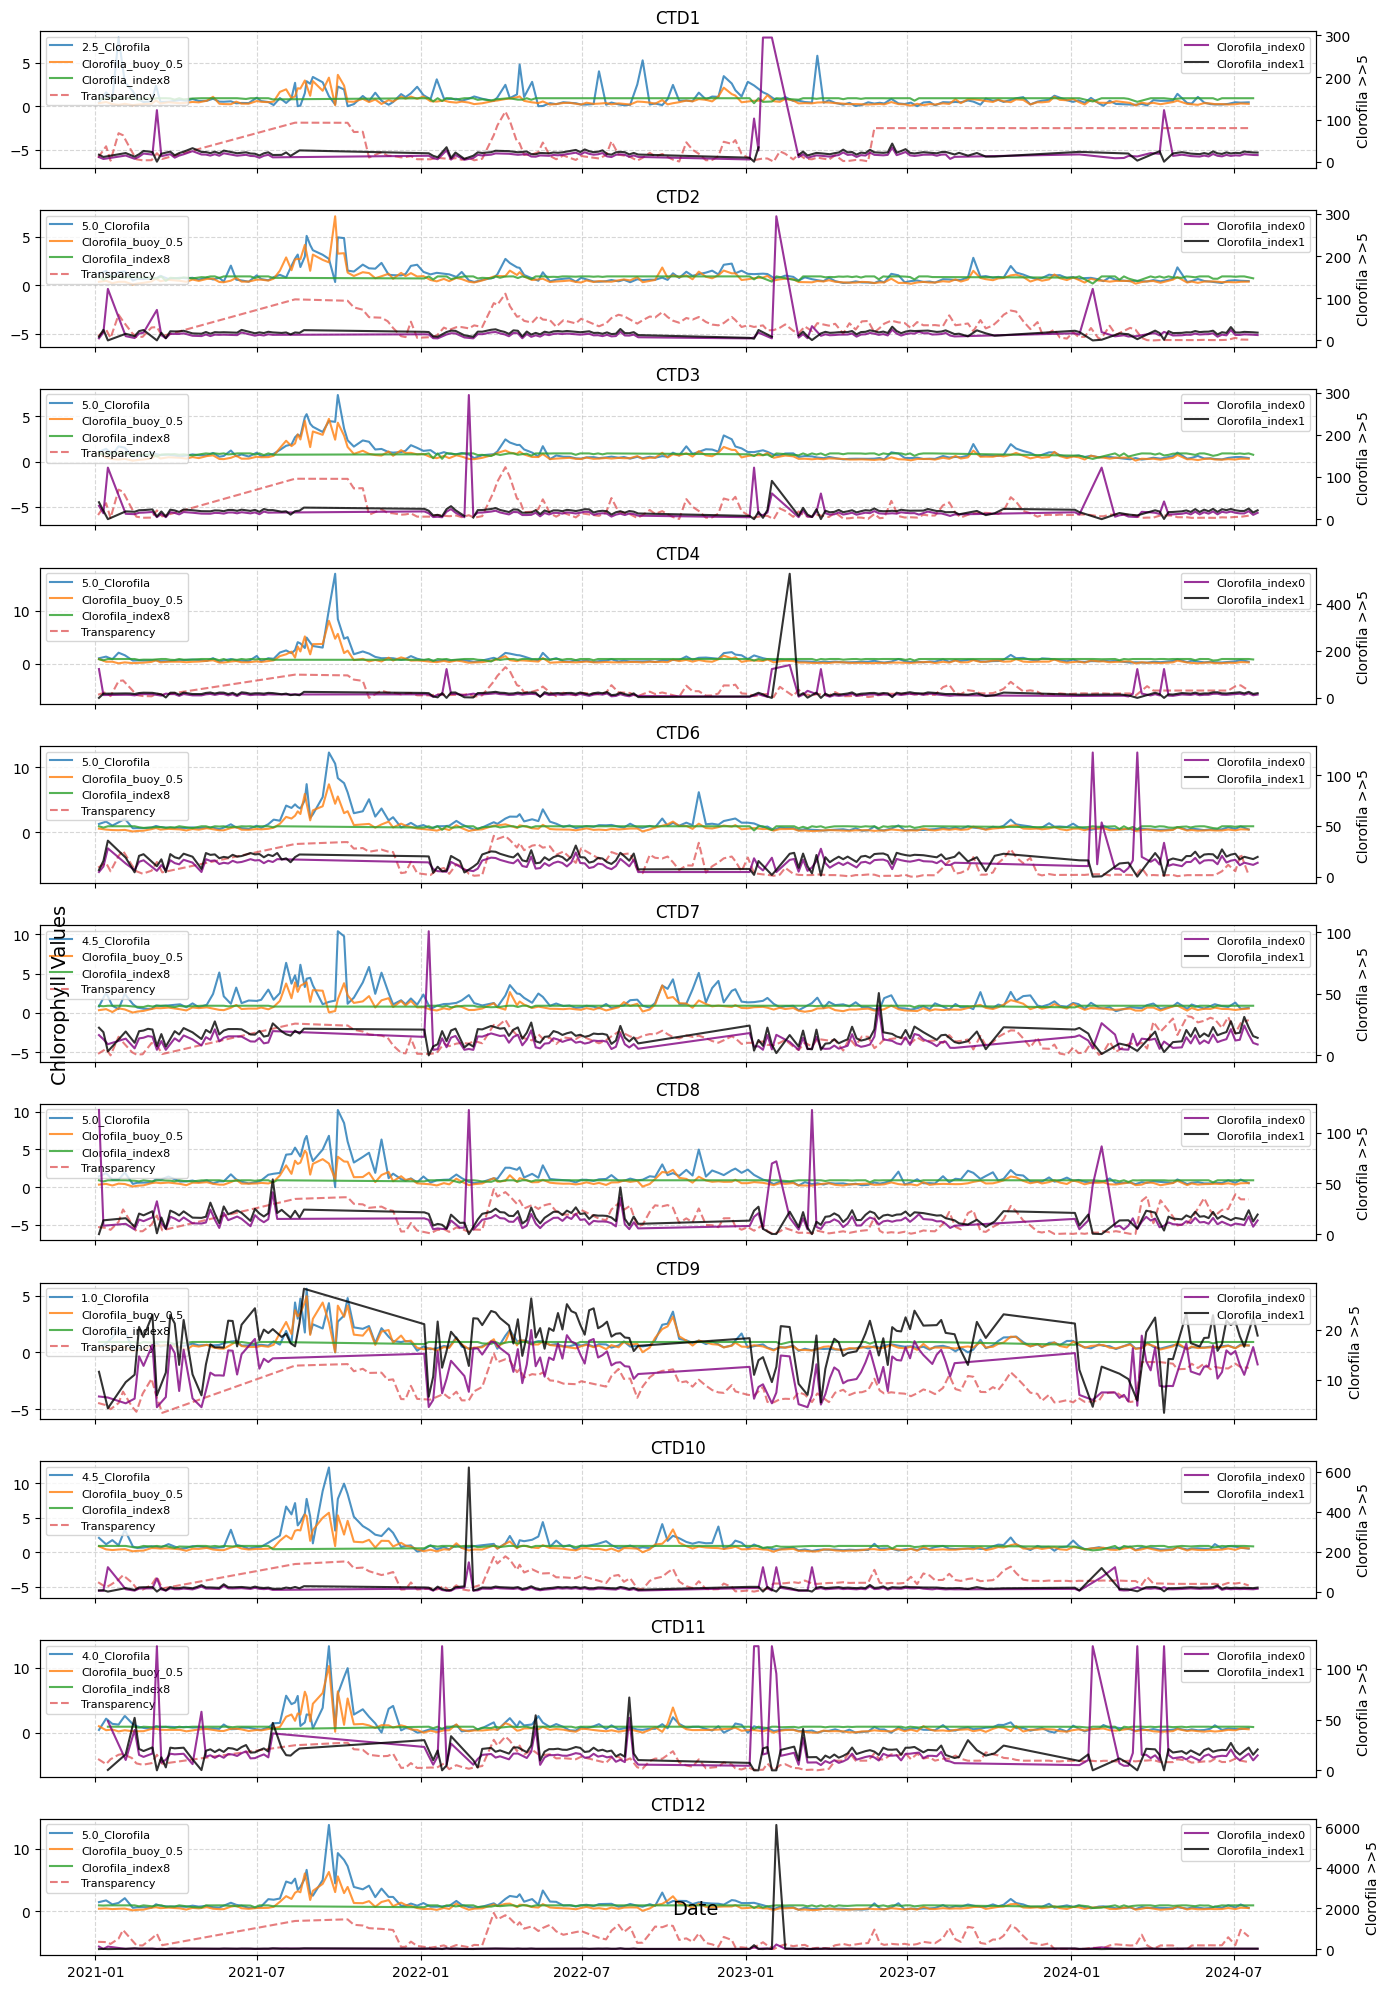

In [67]:
# Define the number of rows and columns for the subplots
nrows, ncols = 11, 1 
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 20), sharex=True, sharey=False)

# Flatten the axes array for easier indexing
axes = axes.flatten()

#merged_dfs = {}

# Loop through each buoy and its corresponding subplot
for i, buoy in enumerate([f"CTD{j}" for j in range(1, 13) if j != 5]):
    ax = axes[i]
    
    merged_df = base_df.merge(dataframes_boyas[f"{buoy}_Clorofila"][["Date", dataframes_boyas[f"{buoy}_Clorofila"].columns[-1]]], on='Date', how='left').rename(columns={dataframes_boyas[f"{buoy}_Clorofila"].columns[-1]: f"{dataframes_boyas[f'{buoy}_Clorofila'].columns[-1]}_Clorofila"})
    merged_df = merged_df.merge(dataframes_buoys_index0[buoy][["Date", "Pixel_Value"]], on='Date', how='left').rename(columns={"Pixel_Value": f"Clorofila_index0_{buoy}"})
    merged_df = merged_df.merge(dataframes_buoys_index1[buoy][["Date", "Pixel_Value"]], on='Date', how='left').rename(columns={"Pixel_Value": f"Clorofila_index1_{buoy}"})
    merged_df = merged_df.merge(dataframes_buoys_index8[buoy][["Date", "Pixel_Value"]], on='Date', how='left').rename(columns={"Pixel_Value": f"Clorofila_index8_{buoy}"})
    merged_df = merged_df.merge(dataframes_boyas[f"{buoy}_Transparency"][["Date", "Transparency"]], on='Date', how='left')

    merged_df_05 = base_df.merge(dataframes_boyas[f"{buoy}_Clorofila"][["Date", "0.5"]], on='Date', how='left').rename(columns={"0.5": f"Clorofila_buoy_{buoy}"})
    merged_df_05 = merged_df_05.merge(dataframes_buoys_index0[buoy][["Date", "Pixel_Value"]], on='Date', how='left').rename(columns={"Pixel_Value": f"Clorofila_index0_{buoy}"})
    merged_df_05 = merged_df_05.merge(dataframes_buoys_index1[buoy][["Date", "Pixel_Value"]], on='Date', how='left').rename(columns={"Pixel_Value": f"Clorofila_index1_{buoy}"})
    merged_df_05 = merged_df_05.merge(dataframes_buoys_index8[buoy][["Date", "Pixel_Value"]], on='Date', how='left').rename(columns={"Pixel_Value": f"Clorofila_index8_{buoy}"})

    if merged_df[f"{dataframes_boyas[f'{buoy}_Clorofila'].columns[-1]}_Clorofila"].notna().any():
        ax.plot(merged_df.dropna(subset=[f"{dataframes_boyas[f'{buoy}_Clorofila'].columns[-1]}_Clorofila"])["Date"],
                merged_df.dropna(subset=[f"{dataframes_boyas[f'{buoy}_Clorofila'].columns[-1]}_Clorofila"])[f"{dataframes_boyas[f'{buoy}_Clorofila'].columns[-1]}_Clorofila"], 
                label=f"{dataframes_boyas[f'{buoy}_Clorofila'].columns[-1]}_Clorofila", alpha=0.8)
    if merged_df_05[f"Clorofila_buoy_{buoy}"].notna().any():
        ax.plot(merged_df_05.dropna(subset=[f"Clorofila_buoy_{buoy}"])["Date"],
                merged_df_05.dropna(subset=[f"Clorofila_buoy_{buoy}"])[f"Clorofila_buoy_{buoy}"], 
                label="Clorofila_buoy_0.5", alpha=0.8)
    if merged_df[f"Clorofila_index8_{buoy}"].notna().any():
        ax.plot(merged_df.dropna(subset=[f"Clorofila_index8_{buoy}"])["Date"],
                merged_df.dropna(subset=[f"Clorofila_index8_{buoy}"])[f"Clorofila_index8_{buoy}"], 
            label="Clorofila_index8", alpha=0.8)

    if merged_df[f"Transparency"].notna().any():
        ax.plot(merged_df.dropna(subset=[f"Transparency"])["Date"],
                merged_df.dropna(subset=[f"Transparency"])[f"Transparency"], 
            label="Transparency", alpha=0.6, linestyle="--")

    ax.set_title(f"{buoy}")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc="upper left", fontsize=8)


    ax2 = ax.twinx()

    if merged_df[f"Clorofila_index0_{buoy}"].notna().any():
        ax2.plot(merged_df.dropna(subset=[f"Clorofila_index0_{buoy}"])["Date"],
                merged_df.dropna(subset=[f"Clorofila_index0_{buoy}"])[f"Clorofila_index0_{buoy}"], 
                label="Clorofila_index0", alpha=0.8, color="purple")
    if merged_df[f"Clorofila_index1_{buoy}"].notna().any():
        ax2.plot(merged_df.dropna(subset=[f"Clorofila_index1_{buoy}"])["Date"],
                merged_df.dropna(subset=[f"Clorofila_index1_{buoy}"])[f"Clorofila_index1_{buoy}"], 
            label="Clorofila_index1", alpha=0.8, color="black")

    ax2.set_ylabel("Clorofila >>5")
    ax2.legend(loc="upper right", fontsize=8)



# Adjust layout and add shared labels
plt.tight_layout()
fig.text(0.5, 0.04, 'Date', ha='center', fontsize=14)
fig.text(0.04, 0.5, 'Chlorophyll Values', va='center', rotation='vertical', fontsize=14)

plt.show()